# Statistics Advance-4 Assignment
### Data Science Masters - PW Skills

## Q1. Difference between t-test and z-test

| Feature | t-test | z-test |
|---|---|---|
| Sample size | Small (n < 30) | Large (n ≥ 30) |
| Population std (σ) | Unknown | Known |
| Distribution used | t-distribution | Standard Normal |
| Parameters | degrees of freedom (df = n-1) | No extra parameter |
| Tails | Heavier tails | Thinner tails |

**Example — t-test:**
A researcher tests a new drug on 20 patients and measures blood pressure change. Population std is unknown → use t-test.

**Example — z-test:**
A factory checks if the average weight of 200 sampled packets equals the claimed 500g. Population std is known from historical data → use z-test.

## Q2. Differentiate between one-tailed and two-tailed tests

| Feature | One-tailed | Two-tailed |
|---|---|---|
| Direction | Only one direction (> or <) | Both directions (≠) |
| Critical region | One side of distribution | Both sides of distribution |
| α split | All α on one side | α/2 on each side |
| Use when | We expect a specific direction | We just check if different |

**One-tailed example:**
H₀: μ ≤ 50, H₁: μ > 50 → testing if mean is specifically GREATER.

**Two-tailed example:**
H₀: μ = 50, H₁: μ ≠ 50 → testing if mean is DIFFERENT in either direction.

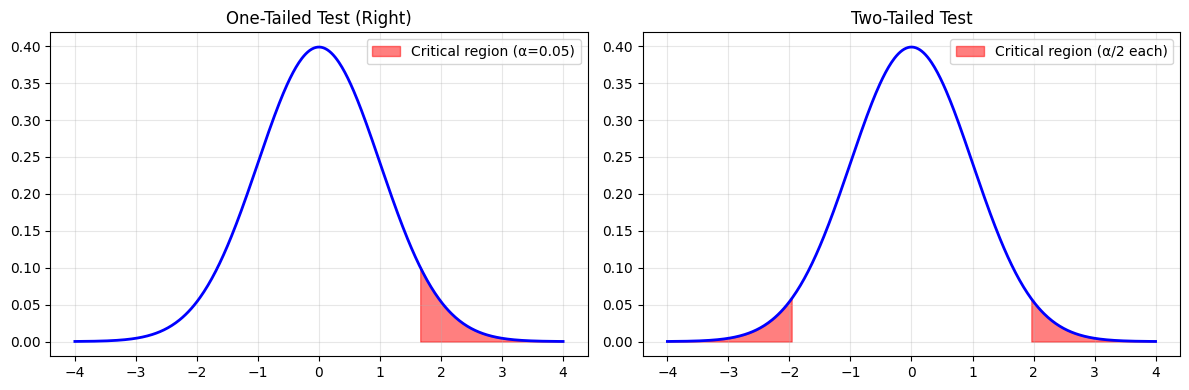

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 500)
y = norm.pdf(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One-tailed (right)
axes[0].plot(x, y, 'b-', linewidth=2)
axes[0].fill_between(x, y, where=(x > 1.645), color='red', alpha=0.5, label='Critical region (α=0.05)')
axes[0].set_title('One-Tailed Test (Right)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Two-tailed
axes[1].plot(x, y, 'b-', linewidth=2)
axes[1].fill_between(x, y, where=(x > 1.96),  color='red', alpha=0.5, label='Critical region (α/2 each)')
axes[1].fill_between(x, y, where=(x < -1.96), color='red', alpha=0.5)
axes[1].set_title('Two-Tailed Test')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Q3. Type 1 and Type 2 Errors in Hypothesis Testing

| | H₀ is True | H₀ is False |
|---|---|---|
| **Reject H₀** | Type 1 Error (False Positive) ❌ | Correct Decision ✅ |
| **Fail to Reject H₀** | Correct Decision ✅ | Type 2 Error (False Negative) ❌ |

---

**Type 1 Error (α — False Positive):**
- Rejecting H₀ when it is actually TRUE.
- Probability = α (significance level)
- Example: A court declares an innocent person GUILTY. The person is actually innocent (H₀ = innocent is true), but we rejected H₀.

---

**Type 2 Error (β — False Negative):**
- Failing to reject H₀ when it is actually FALSE.
- Probability = β; Power of test = 1 - β
- Example: A court declares a guilty person NOT GUILTY. The person is actually guilty (H₀ = innocent is false), but we failed to reject H₀.

---

**Medical Example:**
- Type 1: A healthy person tests POSITIVE for a disease (false alarm).
- Type 2: A sick person tests NEGATIVE for a disease (missed diagnosis).

## Q4. Bayes's Theorem with an example

**Bayes's Theorem:**
Updates the probability of an event based on new evidence.

Formula: **P(A|B) = P(B|A) × P(A) / P(B)**

Where:
- P(A|B) = Posterior — probability of A given B occurred
- P(B|A) = Likelihood — probability of B given A is true
- P(A)   = Prior — initial probability of A
- P(B)   = Marginal probability of B

---

**Example — Medical Test:**
- 1% of population has a disease → P(Disease) = 0.01
- Test is 95% accurate if you have disease → P(Positive | Disease) = 0.95
- Test gives 5% false positive → P(Positive | No Disease) = 0.05

**Question:** If test is positive, what is probability you actually have the disease?

P(B) = P(Pos|Disease)×P(Disease) + P(Pos|No Disease)×P(No Disease)
     = 0.95×0.01 + 0.05×0.99 = 0.0095 + 0.0495 = 0.059

P(Disease|Positive) = 0.95 × 0.01 / 0.059 ≈ 0.161 = **16.1%**

Even with a positive test, only 16% chance of actually having disease — because disease is rare!

In [2]:
# Bayes Theorem calculation
P_disease        = 0.01   # Prior
P_no_disease     = 1 - P_disease
P_pos_disease    = 0.95   # Likelihood
P_pos_no_disease = 0.05   # False positive rate

# Total probability of positive test
P_positive = (P_pos_disease * P_disease) + (P_pos_no_disease * P_no_disease)

# Posterior
P_disease_given_pos = (P_pos_disease * P_disease) / P_positive

print("===== Bayes Theorem — Medical Test =====")
print(f"P(Disease)              : {P_disease}")
print(f"P(Positive | Disease)   : {P_pos_disease}")
print(f"P(Positive | No Disease): {P_pos_no_disease}")
print(f"P(Positive)             : {P_positive:.4f}")
print(f"\nP(Disease | Positive)   : {P_disease_given_pos:.4f} = {P_disease_given_pos*100:.1f}%")
print("\nConclusion: Even with positive test, only ~16% chance of actually having disease!")

===== Bayes Theorem — Medical Test =====
P(Disease)              : 0.01
P(Positive | Disease)   : 0.95
P(Positive | No Disease): 0.05
P(Positive)             : 0.0590

P(Disease | Positive)   : 0.1610 = 16.1%

Conclusion: Even with positive test, only ~16% chance of actually having disease!


## Q5. What is a Confidence Interval? How to calculate it?

**Confidence Interval (CI):**
A range of values that likely contains the true population parameter with a certain level of confidence.

- 95% CI means: If we repeat sampling 100 times, ~95 intervals will contain the true population mean.

**Formula:**
CI = x̄ ± Z* × (σ / √n)   → when σ known (z-interval)
CI = x̄ ± t* × (s / √n)   → when σ unknown (t-interval)

**Steps:**
1. Calculate sample mean (x̄)
2. Find critical value (Z* or t*) for desired confidence level
3. Calculate standard error = s / √n
4. Margin of Error = critical value × standard error
5. CI = (x̄ - MoE, x̄ + MoE)

In [3]:
import numpy as np
from scipy import stats

# Example: Sample of 40 students, mean=75, std=10, 95% CI
n           = 40
sample_mean = 75
sample_std  = 10
confidence  = 0.95

t_critical      = stats.t.ppf((1 + confidence) / 2, df=n-1)
margin_of_error = t_critical * (sample_std / np.sqrt(n))
lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print("===== Confidence Interval Example =====")
print(f"Sample mean     : {sample_mean}")
print(f"Sample std      : {sample_std}")
print(f"n               : {n}")
print(f"t-critical      : {t_critical:.4f}")
print(f"Margin of Error : {margin_of_error:.4f}")
print(f"95% CI          : ({lower:.2f}, {upper:.2f})")
print(f"\nInterpretation: We are 95% confident true population mean lies between {lower:.2f} and {upper:.2f}.")

===== Confidence Interval Example =====
Sample mean     : 75
Sample std      : 10
n               : 40
t-critical      : 2.0227
Margin of Error : 3.1982
95% CI          : (71.80, 78.20)

Interpretation: We are 95% confident true population mean lies between 71.80 and 78.20.


## Q6. Bayes' Theorem — Sample Problem and Solution

In [4]:
"""
Problem:
An email spam filter needs to classify emails.
- 30% of all emails are spam        → P(Spam) = 0.30
- 70% of all emails are not spam    → P(Not Spam) = 0.70
- If email is spam, 90% contain word 'FREE'    → P(FREE | Spam) = 0.90
- If email is not spam, 10% contain word 'FREE'→ P(FREE | Not Spam) = 0.10

Question: If an email contains 'FREE', what is P(Spam | FREE)?
"""

P_spam        = 0.30
P_not_spam    = 0.70
P_free_spam   = 0.90
P_free_nspam  = 0.10

# Total P(FREE)
P_free = (P_free_spam * P_spam) + (P_free_nspam * P_not_spam)

# Bayes
P_spam_given_free = (P_free_spam * P_spam) / P_free

print("===== Spam Filter — Bayes Theorem =====")
print(f"P(Spam)              : {P_spam}")
print(f"P(FREE | Spam)       : {P_free_spam}")
print(f"P(FREE | Not Spam)   : {P_free_nspam}")
print(f"P(FREE)              : {P_free:.4f}")
print(f"\nP(Spam | FREE)       : {P_spam_given_free:.4f} = {P_spam_given_free*100:.1f}%")
print("\nConclusion: If email contains 'FREE', there is ~79.4% probability it is spam!")

===== Spam Filter — Bayes Theorem =====
P(Spam)              : 0.3
P(FREE | Spam)       : 0.9
P(FREE | Not Spam)   : 0.1
P(FREE)              : 0.3400

P(Spam | FREE)       : 0.7941 = 79.4%

Conclusion: If email contains 'FREE', there is ~79.4% probability it is spam!


## Q7. 95% Confidence Interval — mean=50, std=5

In [5]:
import numpy as np
from scipy import stats

# Given (assuming sample size n=30 since not specified)
sample_mean = 50
sample_std  = 5
n           = 30
confidence  = 0.95

# Z-critical for 95%
z_critical      = stats.norm.ppf((1 + confidence) / 2)
margin_of_error = z_critical * (sample_std / np.sqrt(n))
lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print("===== 95% Confidence Interval =====")
print(f"Sample Mean     : {sample_mean}")
print(f"Sample Std      : {sample_std}")
print(f"n               : {n}")
print(f"Z-critical      : {z_critical:.4f}")
print(f"Margin of Error : {margin_of_error:.4f}")
print(f"\n95% CI: ({lower:.2f}, {upper:.2f})")
print(f"\nInterpretation: We are 95% confident the true population mean")
print(f"lies between {lower:.2f} and {upper:.2f}.")

===== 95% Confidence Interval =====
Sample Mean     : 50
Sample Std      : 5
n               : 30
Z-critical      : 1.9600
Margin of Error : 1.7892

95% CI: (48.21, 51.79)

Interpretation: We are 95% confident the true population mean
lies between 48.21 and 51.79.


## Q8. Margin of Error — what it is + effect of sample size

**Margin of Error (MoE):**
The maximum expected difference between the sample estimate and the true population parameter.

Formula: MoE = Z* × (σ / √n)

**Effect of Sample Size on MoE:**
- MoE ∝ 1/√n → as n increases, MoE decreases.
- Larger sample → more accurate estimate → smaller margin of error.
- To halve the MoE, you need to quadruple the sample size!

**Example Scenario:**
An election poll wants to estimate the % of voters supporting a candidate.
- With n=100: MoE = ±9.8%
- With n=500: MoE = ±4.4%
- With n=1000: MoE = ±3.1%

Larger sample → more precise poll!

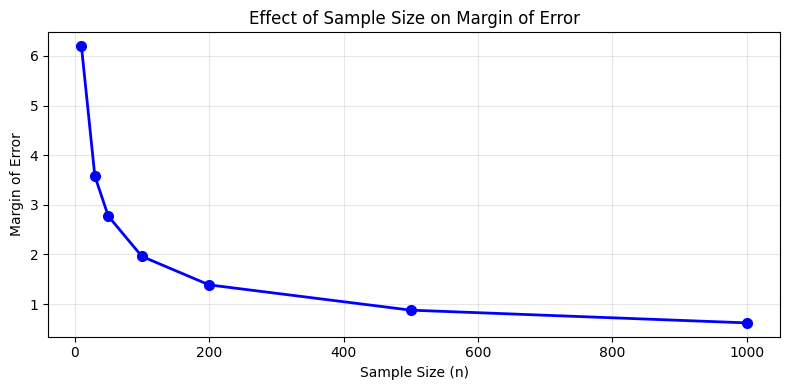

Sample Size vs Margin of Error (σ=10, 95% CI):
  n=10    → MoE = 6.1980
  n=30    → MoE = 3.5784
  n=50    → MoE = 2.7718
  n=100   → MoE = 1.9600
  n=200   → MoE = 1.3859
  n=500   → MoE = 0.8765
  n=1000  → MoE = 0.6198


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sigma      = 10
z_critical = stats.norm.ppf(0.975)  # 95% CI
sample_sizes = [10, 30, 50, 100, 200, 500, 1000]
moe_values   = [z_critical * (sigma / np.sqrt(n)) for n in sample_sizes]

plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, moe_values, 'bo-', linewidth=2, markersize=7)
plt.title('Effect of Sample Size on Margin of Error')
plt.xlabel('Sample Size (n)')
plt.ylabel('Margin of Error')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Sample Size vs Margin of Error (σ=10, 95% CI):")
for n, moe in zip(sample_sizes, moe_values):
    print(f"  n={n:<5} → MoE = {moe:.4f}")

## Q9. Z-score calculation — x=75, μ=70, σ=5

In [7]:
from scipy import stats

x   = 75
mu  = 70
sigma = 5

z = (x - mu) / sigma

# What % of data falls below this point
percentile = stats.norm.cdf(z) * 100

print("===== Z-score Calculation =====")
print(f"x = {x}, μ = {mu}, σ = {sigma}")
print(f"\nZ = (x - μ) / σ = ({x} - {mu}) / {sigma} = {z}")
print(f"\nInterpretation:")
print(f"  → The data point 75 is {z} standard deviation(s) ABOVE the mean.")
print(f"  → It is higher than {percentile:.2f}% of all values in the distribution.")

===== Z-score Calculation =====
x = 75, μ = 70, σ = 5

Z = (x - μ) / σ = (75 - 70) / 5 = 1.0

Interpretation:
  → The data point 75 is 1.0 standard deviation(s) ABOVE the mean.
  → It is higher than 84.13% of all values in the distribution.


## Q10. Hypothesis test — Weight loss drug (95% confidence, t-test)

In [8]:
import numpy as np
from scipy import stats

# Given
n           = 50
sample_mean = 6      # pounds lost
sample_std  = 2.5
mu_0        = 0      # H0: drug has no effect (mean loss = 0)
alpha       = 0.05   # 95% confidence

# H0: μ = 0 (no weight loss)
# H1: μ > 0 (drug causes weight loss) — one-tailed right

t_stat  = (sample_mean - mu_0) / (sample_std / np.sqrt(n))
p_value = stats.t.sf(t_stat, df=n-1)  # one-tailed right

print("===== Weight Loss Drug — Hypothesis Test =====")
print(f"H₀: μ = 0 (drug has no effect)")
print(f"H₁: μ > 0 (drug causes weight loss)")
print(f"\nSample mean : {sample_mean} pounds")
print(f"Sample std  : {sample_std}")
print(f"n           : {n}")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"Alpha       : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — Drug is significantly effective at 95% confidence level.")
else:
    print("\nResult: FAIL TO REJECT H₀ — Drug is NOT significantly effective.")

===== Weight Loss Drug — Hypothesis Test =====
H₀: μ = 0 (drug has no effect)
H₁: μ > 0 (drug causes weight loss)

Sample mean : 6 pounds
Sample std  : 2.5
n           : 50
t-statistic : 16.9706
p-value     : 0.000000
Alpha       : 0.05

Result: REJECT H₀ — Drug is significantly effective at 95% confidence level.


## Q11. 95% CI for proportion — 65% of 500 people satisfied with job

In [9]:
import numpy as np
from scipy import stats

# Given
n          = 500
p_hat      = 0.65   # sample proportion
confidence = 0.95

# Z-critical
z_critical = stats.norm.ppf((1 + confidence) / 2)

# Standard error for proportion
se = np.sqrt((p_hat * (1 - p_hat)) / n)

margin_of_error = z_critical * se
lower = p_hat - margin_of_error
upper = p_hat + margin_of_error

print("===== 95% CI for Proportion — Job Satisfaction =====")
print(f"Sample proportion (p̂) : {p_hat} (65%)")
print(f"Sample size (n)        : {n}")
print(f"Z-critical             : {z_critical:.4f}")
print(f"Standard Error         : {se:.4f}")
print(f"Margin of Error        : {margin_of_error:.4f}")
print(f"\n95% CI: ({lower:.4f}, {upper:.4f})")
print(f"       = ({lower*100:.2f}%, {upper*100:.2f}%)")
print(f"\nInterpretation: We are 95% confident that the true proportion of satisfied")
print(f"employees lies between {lower*100:.2f}% and {upper*100:.2f}%.")

===== 95% CI for Proportion — Job Satisfaction =====
Sample proportion (p̂) : 0.65 (65%)
Sample size (n)        : 500
Z-critical             : 1.9600
Standard Error         : 0.0213
Margin of Error        : 0.0418

95% CI: (0.6082, 0.6918)
       = (60.82%, 69.18%)

Interpretation: We are 95% confident that the true proportion of satisfied
employees lies between 60.82% and 69.18%.


## Q12. Two-sample t-test — Two teaching methods (α=0.01)

In [10]:
import numpy as np
from scipy import stats

# Given (assuming equal sample sizes n=30 since not specified)
n1, mean1, std1 = 30, 85, 6
n2, mean2, std2 = 30, 82, 5
alpha = 0.01

# H0: μ1 = μ2
# H1: μ1 ≠ μ2 (two-tailed)

# Welch's t-test (unequal variances)
se     = np.sqrt((std1**2 / n1) + (std2**2 / n2))
t_stat = (mean1 - mean2) / se
df     = ((std1**2/n1 + std2**2/n2)**2) / \
         ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))

p_value = 2 * stats.t.sf(abs(t_stat), df=df)

print("===== Two Teaching Methods — Hypothesis Test =====")
print(f"H₀: μ₁ = μ₂  |  H₁: μ₁ ≠ μ₂ (two-tailed)")
print(f"\nSample A → mean={mean1}, std={std1}, n={n1}")
print(f"Sample B → mean={mean2}, std={std2}, n={n2}")
print(f"t-statistic : {t_stat:.4f}")
print(f"df          : {df:.2f}")
print(f"p-value     : {p_value:.4f}")
print(f"Alpha       : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — Significant difference exists between the two teaching methods.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant difference between the two teaching methods.")

===== Two Teaching Methods — Hypothesis Test =====
H₀: μ₁ = μ₂  |  H₁: μ₁ ≠ μ₂ (two-tailed)

Sample A → mean=85, std=6, n=30
Sample B → mean=82, std=5, n=30
t-statistic : 2.1039
df          : 56.17
p-value     : 0.0399
Alpha       : 0.01

Result: FAIL TO REJECT H₀ — No significant difference between the two teaching methods.


## Q13. 90% CI — Population mean=60, std=8, sample n=50, x̄=65

In [11]:
import numpy as np
from scipy import stats

# Given
pop_mean   = 60   # population mean (known but we calculate CI for sample)
pop_std    = 8    # population std (known) → use z-test
n          = 50
x_bar      = 65   # sample mean
confidence = 0.90

z_critical      = stats.norm.ppf((1 + confidence) / 2)
margin_of_error = z_critical * (pop_std / np.sqrt(n))
lower = x_bar - margin_of_error
upper = x_bar + margin_of_error

print("===== 90% Confidence Interval =====")
print(f"Population std (σ) : {pop_std}")
print(f"Sample mean (x̄)   : {x_bar}")
print(f"n                  : {n}")
print(f"Z-critical (90%)   : {z_critical:.4f}")
print(f"Margin of Error    : {margin_of_error:.4f}")
print(f"\n90% CI: ({lower:.2f}, {upper:.2f})")
print(f"\nInterpretation: We are 90% confident the true population mean")
print(f"lies between {lower:.2f} and {upper:.2f}.")

===== 90% Confidence Interval =====
Population std (σ) : 8
Sample mean (x̄)   : 65
n                  : 50
Z-critical (90%)   : 1.6449
Margin of Error    : 1.8609

90% CI: (63.14, 66.86)

Interpretation: We are 90% confident the true population mean
lies between 63.14 and 66.86.


## Q14. Hypothesis test — Caffeine effect on reaction time (90% confidence, t-test)

In [12]:
import numpy as np
from scipy import stats

# Given
n           = 30
sample_mean = 0.25   # seconds
sample_std  = 0.05
mu_0        = 0.30   # assumed normal reaction time without caffeine
alpha       = 0.10   # 90% confidence → α = 0.10

# H0: μ = 0.30 (caffeine has no effect)
# H1: μ ≠ 0.30 (caffeine has significant effect) — two-tailed

t_stat  = (sample_mean - mu_0) / (sample_std / np.sqrt(n))
p_value = 2 * stats.t.sf(abs(t_stat), df=n-1)  # two-tailed

print("===== Caffeine Effect on Reaction Time — Hypothesis Test =====")
print(f"H₀: μ = 0.30 seconds (no effect)")
print(f"H₁: μ ≠ 0.30 seconds (significant effect) — two-tailed")
print(f"\nSample mean : {sample_mean} sec")
print(f"Sample std  : {sample_std}")
print(f"n           : {n}")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"Alpha       : {alpha} (90% confidence)")

if p_value < alpha:
    print("\nResult: REJECT H₀ — Caffeine has a significant effect on reaction time at 90% confidence.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant effect of caffeine on reaction time.")

===== Caffeine Effect on Reaction Time — Hypothesis Test =====
H₀: μ = 0.30 seconds (no effect)
H₁: μ ≠ 0.30 seconds (significant effect) — two-tailed

Sample mean : 0.25 sec
Sample std  : 0.05
n           : 30
t-statistic : -5.4772
p-value     : 0.000007
Alpha       : 0.1 (90% confidence)

Result: REJECT H₀ — Caffeine has a significant effect on reaction time at 90% confidence.
